PHASE 1

In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np
import cv2
import os

In [3]:
import matplotlib.pyplot as plt

In [4]:
# 1. File paths define karna (Apne computer ke according paths set karein)
metadata_csv_path = r"C:\Users\user2\Desktop\Khushi Jha\isic-2019-dataset-full\ISIC_2019_Training_Metadata.csv"
groundtruth_csv_path = r"C:\Users\user2\Desktop\Khushi Jha\isic-2019-dataset-full\ISIC_2019_Training_GroundTruth.csv"
train_images_folder = r"C:\Users\user2\Desktop\Khushi Jha\isic-2019-dataset-full\train" # Naya train folder path
test_metadata_csv_path = r"C:\Users\user2\Desktop\Khushi Jha\isic-2019-dataset-full\ISIC_2019_Test_Metadata.csv"

In [5]:
# 2. Dono CSV files ko memory (Pandas DataFrame) mein load karna
metadata_df = pd.read_csv(metadata_csv_path)
gt_df = pd.read_csv(groundtruth_csv_path)
test_metadata_df = pd.read_csv(test_metadata_csv_path)


In [6]:
print(metadata_df.shape)
print(gt_df.shape)
print(test_metadata_df)

(25331, 5)
(25331, 10)
             image  age_approx anatom_site_general     sex
0     ISIC_0034321        60.0                 NaN  female
1     ISIC_0034322        70.0      anterior torso    male
2     ISIC_0034323        70.0     lower extremity    male
3     ISIC_0034324        70.0     lower extremity    male
4     ISIC_0034325        30.0     upper extremity  female
...            ...         ...                 ...     ...
8233  ISIC_0073236        75.0      anterior torso    male
8234  ISIC_0073243        65.0     lower extremity    male
8235  ISIC_0073250        30.0      anterior torso  female
8236  ISIC_0073252        85.0           head/neck  female
8237  ISIC_0073253        70.0      anterior torso    male

[8238 rows x 4 columns]


In [7]:
print(metadata_df.head())
print(gt_df.head())

          image  age_approx anatom_site_general lesion_id     sex
0  ISIC_0000000        55.0      anterior torso       NaN  female
1  ISIC_0000001        30.0      anterior torso       NaN  female
2  ISIC_0000002        60.0     upper extremity       NaN  female
3  ISIC_0000003        30.0     upper extremity       NaN    male
4  ISIC_0000004        80.0     posterior torso       NaN    male
          image  MEL   NV  BCC   AK  BKL   DF  VASC  SCC  UNK
0  ISIC_0000000  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
1  ISIC_0000001  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
2  ISIC_0000002  1.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
3  ISIC_0000003  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
4  ISIC_0000004  1.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0


In [8]:
gt_df["target"] = gt_df["MEL"]

print(gt_df["target"].value_counts())

target
0.0    20809
1.0     4522
Name: count, dtype: int64


In [9]:
# 3. Dataframes ko MERGE karna
# Dono files mein 'image' naam ka column common hota hai. Hum uspe inko jodenge.
train_df = pd.merge(metadata_df, gt_df[["image","target"]], on='image',how = "inner")
print(train_df.columns.tolist())

['image', 'age_approx', 'anatom_site_general', 'lesion_id', 'sex', 'target']


In [10]:
train_df["image_path"] = train_df["image"].apply(
    lambda x: os.path.join(train_images_folder, x + ".jpg")
)
train_df[["image","image_path"]].head()


,image,image_path
0,ISIC_0000000,C:\Users\user2\Desktop\Khushi Jha\isic-2019-da...
1,ISIC_0000001,C:\Users\user2\Desktop\Khushi Jha\isic-2019-da...
2,ISIC_0000002,C:\Users\user2\Desktop\Khushi Jha\isic-2019-da...
3,ISIC_0000003,C:\Users\user2\Desktop\Khushi Jha\isic-2019-da...
4,ISIC_0000004,C:\Users\user2\Desktop\Khushi Jha\isic-2019-da...


In [11]:
print(len(train_df))

25331


In [12]:
missing = []

for path in train_df["image_path"]:
    if not os.path.exists(path):
        missing.append(path)

print("Missing images:", len(missing))

Missing images: 0


In [13]:
print("Total Samples:", len(train_df))

print("\nTarget Distribution")
print(train_df["target"].value_counts())

print("\nSex Distribution")
print(train_df["sex"].value_counts())

print("\nMissing Values")
print(train_df.isnull().sum())

Total Samples: 25331

Target Distribution
target
0.0    20809
1.0     4522
Name: count, dtype: int64

Sex Distribution
sex
male      13286
female    11661
Name: count, dtype: int64

Missing Values
image                     0
age_approx              437
anatom_site_general    2631
lesion_id              2084
sex                     384
target                    0
image_path                0
dtype: int64


In [14]:
train_df.to_csv("merged_training_data.csv",index=False)

PHASE 2

In [15]:
print(metadata_df.columns)
print(gt_df.columns)
print(test_metadata_df.columns)

Index(['image', 'age_approx', 'anatom_site_general', 'lesion_id', 'sex'], dtype='str')
Index(['image', 'MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK',
       'target'],
      dtype='str')
Index(['image', 'age_approx', 'anatom_site_general', 'sex'], dtype='str')


In [16]:
import pandas as pd

train_df = pd.read_csv("merged_training_data.csv")

print(train_df.head())

          image  age_approx anatom_site_general lesion_id     sex  target  \
0  ISIC_0000000        55.0      anterior torso       NaN  female     0.0   
1  ISIC_0000001        30.0      anterior torso       NaN  female     0.0   
2  ISIC_0000002        60.0     upper extremity       NaN  female     1.0   
3  ISIC_0000003        30.0     upper extremity       NaN    male     0.0   
4  ISIC_0000004        80.0     posterior torso       NaN    male     1.0   

                                          image_path  
0  C:\Users\user2\Desktop\Khushi Jha\isic-2019-da...  
1  C:\Users\user2\Desktop\Khushi Jha\isic-2019-da...  
2  C:\Users\user2\Desktop\Khushi Jha\isic-2019-da...  
3  C:\Users\user2\Desktop\Khushi Jha\isic-2019-da...  
4  C:\Users\user2\Desktop\Khushi Jha\isic-2019-da...  


In [17]:
print(train_df.isnull().sum())

image                     0
age_approx              437
anatom_site_general    2631
lesion_id              2084
sex                     384
target                    0
image_path                0
dtype: int64


In [18]:
#Handle missing age: average

age_median = train_df["age_approx"].median()

train_df["age_approx"] = train_df["age_approx"].fillna(age_median)

print(train_df["age_approx"].isnull().sum())

0


In [19]:
# handle missing sex : categorical 
sex_mode = train_df["sex"].mode()[0]

train_df["sex"] = train_df["sex"].fillna(sex_mode)

print(train_df["sex"].isnull().sum())

0


In [20]:
# handle missing anatomical site : categorical 
 
site_mode = train_df["anatom_site_general"].mode()[0]

train_df["anatom_site_general"] = (
    train_df["anatom_site_general"]
    .fillna(site_mode)
)
print(train_df["anatom_site_general"].isnull().sum()) 

0


In [21]:
train_df = train_df.drop(columns=["lesion_id"], errors="ignore")  # remove unecessary columns 

In [22]:
train_df.columns

Index(['image', 'age_approx', 'anatom_site_general', 'sex', 'target',
       'image_path'],
      dtype='str')

In [23]:
# encode sex: as neural netwrk cant read text male or female.
train_df["sex"] = train_df["sex"].map({"male":0,"female":1})

In [24]:
print(train_df["sex"].unique())

[1 0]


In [25]:
# one hot encoding 

site_encoded = pd.get_dummies(train_df["anatom_site_general"],prefix="site")

train_df= pd.concat([train_df, site_encoded],axis=1)

train_df.drop(columns=["anatom_site_general"],inplace=True)

In [26]:
print(train_df.head())

          image  age_approx  sex  target  \
0  ISIC_0000000        55.0    1     0.0   
1  ISIC_0000001        30.0    1     0.0   
2  ISIC_0000002        60.0    1     1.0   
3  ISIC_0000003        30.0    0     0.0   
4  ISIC_0000004        80.0    0     1.0   

                                          image_path  site_anterior torso  \
0  C:\Users\user2\Desktop\Khushi Jha\isic-2019-da...                 True   
1  C:\Users\user2\Desktop\Khushi Jha\isic-2019-da...                 True   
2  C:\Users\user2\Desktop\Khushi Jha\isic-2019-da...                False   
3  C:\Users\user2\Desktop\Khushi Jha\isic-2019-da...                False   
4  C:\Users\user2\Desktop\Khushi Jha\isic-2019-da...                False   

   site_head/neck  site_lateral torso  site_lower extremity  \
0           False               False                 False   
1           False               False                 False   
2           False               False                 False   
3           False   

In [27]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_df["age_approx"] = scaler.fit_transform(
    train_df[["age_approx"]]
)
print(train_df["age_approx"].min())
print(train_df["age_approx"].max())

0.0
1.0


In [28]:
# feature columns 
metadata_columns = [col
    for col in train_df.columns
    if col not in ["image","image_path","target"]]
print(metadata_columns)

['age_approx', 'sex', 'site_anterior torso', 'site_head/neck', 'site_lateral torso', 'site_lower extremity', 'site_oral/genital', 'site_palms/soles', 'site_posterior torso', 'site_upper extremity']


In [29]:
# metadata array 
X_meta = train_df[metadata_columns].values

print(X_meta.shape)

(25331, 10)


In [30]:
# prepare labels 

y = train_df["target"].values

print(y.shape)

(25331,)


In [31]:
#### 2. image processing ####
import cv2
import numpy as np

IMG_SIZE = 224

In [32]:
def load_image(path):

    image = cv2.imread(path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    image = cv2.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    image = image.astype(np.float32)

    image = image / 255.0

    return image

In [33]:
#print(image.shape)

In [34]:
sample_image = load_image(
    train_df["image_path"].iloc[0]
)

print(sample_image.shape)

(224, 224, 3)


In [35]:
# check normalization
print(sample_image.min())
print(sample_image.max())

0.06666667
1.0


In [36]:
# create image paths array 
image_paths = train_df["image_path"].values
print(image_paths[:5])

<StringArray>
['C:\Users\user2\Desktop\Khushi Jha\isic-2019-dataset-full\train\ISIC_0000000.jpg',
 'C:\Users\user2\Desktop\Khushi Jha\isic-2019-dataset-full\train\ISIC_0000001.jpg',
 'C:\Users\user2\Desktop\Khushi Jha\isic-2019-dataset-full\train\ISIC_0000002.jpg',
 'C:\Users\user2\Desktop\Khushi Jha\isic-2019-dataset-full\train\ISIC_0000003.jpg',
 'C:\Users\user2\Desktop\Khushi Jha\isic-2019-dataset-full\train\ISIC_0000004.jpg']
Length: 5, dtype: str


In [37]:
#train test split 

from sklearn.model_selection import train_test_split


(train_paths,val_paths,train_meta,val_meta,y_train,y_val) = train_test_split(image_paths,X_meta,y,test_size=0.25,stratify=y,random_state=42)
print(len(train_paths))
print(len(val_paths))

18998
6333


In [38]:
print(train_df.shape)
print(X_meta.shape)
print(y.shape)
print(train_meta.shape)

(25331, 13)
(25331, 10)
(25331,)
(18998, 10)


In [39]:
print(metadata_columns)

['age_approx', 'sex', 'site_anterior torso', 'site_head/neck', 'site_lateral torso', 'site_lower extremity', 'site_oral/genital', 'site_palms/soles', 'site_posterior torso', 'site_upper extremity']


In [41]:
print(tf.__version__)

2.20.0


In [43]:
print(X_meta.shape)

(25331, 10)


PHASE 3

In [59]:
IMG_SIZE = 224

META_DIM = 10

In [60]:
import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Dense,
    GlobalAveragePooling2D,
    BatchNormalization,
    Dropout
)

from tensorflow.keras.models import Model

In [61]:
import tensorflow as tf
import ssl

# Add this to bypass the SSL certificate check
ssl._create_default_https_context = ssl._create_unverified_context



In [62]:
# 1. Image ke liye entry gate (Input Layer)
image_input = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")

# 2. Pre-trained CNN Model load karna (bina top classification layer ke)
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_tensor=image_input
)

# Hum base CNN ko freeze kar rahe hain taaki iske pehle se seekhe hue visual patterns destroy na hon
base_model.trainable = False 

# 3. GlobalAveragePooling lagakar CNN ke 2D output ko 1D vector mein flatten karna
image_features = GlobalAveragePooling2D()(base_model.output)
image_features = BatchNormalization()(image_features)

# 4. Image Projection Layer (Isko align karke 256 shape ka vector banaya)
image_features = Dense(256, activation="relu", name="image_projection")(image_features)

In [ ]:
# 1. Metadata ke liye entry gate (Input Layer for 10 features)
meta_input = Input(shape=(META_DIM,), name="meta_input")

# 2. First Dense Block
meta_features = Dense(64, activation="relu")(meta_input)
meta_features = BatchNormalization()(meta_features)
meta_features = Dense(128, activation="relu")(meta_features)
meta_features = Dense(256, activation="relu", name="metadata_projection")(meta_features)

In [63]:
print(image_features.shape)
print(meta_features.shape)

(None, 256)
(None, 256)


PHASE 4


In [64]:
from tensorflow.keras.layers import Concatenate, Reshape
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, Add, Dense, Dropout

In [65]:
# 1. Dono experts (Visual aur Clinical) ke 256-dim vectors ko aapas mein jodna
# Output dimension banega: 256 (image) + 256 (meta) = 512
combined_features = Concatenate()([image_features, meta_features])

# 2. Transformer hamesha "Sequence" format mein data read karta hai (jaise words in a sentence)
# Isliye humne 1D vector ko ek (1, 512) length ki sequence mein convert (Reshape) kar diya
combined_sequence = Reshape((1, 512))(combined_features)

In [66]:
# 3. Transformer Attention Mechanism lagana
# num_heads=4 ka matlab hai model 4 alag-alag angles se image aur metadata ka cross-connection check karega
attention_output = MultiHeadAttention(
    num_heads=4, 
    key_dim=128
)(combined_sequence, combined_sequence) # Yahan sequence khud ke sath hi compare ho rahi hai (Self-Attention)

In [67]:
# 4. Residual Connection (Skip connection) add karna
# Transformer ko initial raw data yaad dilaane ke liye Add() lagaya gaya
transformer_out = Add()([combined_sequence, attention_output])
transformer_out = LayerNormalization()(transformer_out)

# 5. Feed Forward Network (FFN) inside Transformer
# Yeh dense network sequence ki non-linearities ko aur deep learn karega
ffn_out = Dense(512, activation="relu")(transformer_out)
ffn_out = Dropout(0.3)(ffn_out) # Overfitting rokne ke liye
ffn_out = Dense(512, activation="relu")(ffn_out)

# 6. Final Add and Norm (Ek baar phir skip connection aur normalization)
transformer_out = Add()([transformer_out, ffn_out])
final_features = LayerNormalization()(transformer_out)

PHASE 5

In [68]:
from tensorflow.keras.layers import GlobalAveragePooling1D
from tensorflow.keras.models import Model

# 1. Transformer ke output (Sequence) ko wapas 1D Vector mein laana
# final_features ki shape yahan (1, 512) thi, Pooling isey (512,) kar dega
pooled_features = GlobalAveragePooling1D()(final_features)

# 2. Final Output Layer (Classification)
# 1 neuron with Sigmoid activation (Output probability dega 0 to 1)
final_output = Dense(1, activation='sigmoid', name="binary_classification")(pooled_features)

# 3. Pura Model Compile karna (Input se lekar Output tak bind karna)
# Humne Model ko bataya ki uske 2 inputs hain aur 1 output hai
model = Model(
    inputs=[image_input, meta_input], 
    outputs=final_output,
    name="XAAI_Ledger_Framework"
)

In [69]:
# Model ka engine set karna
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), # Slow aur stable learning ke liye
    loss='binary_crossentropy', # Binary classification ke liye standard loss function
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc') # Paper ki main experimental metric
    ]
)

print("--- Model Structural Layout ---")
model.summary() # Yeh poora framework print karega

--- Model Structural Layout ---


Model: "XAAI_Ledger_Framework"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_16        │ (None, 224, 224,  │          0 │ image_input[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_8     │ (None, 224, 224,  │          7 │ rescaling_16[0][… │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_17        │ (None, 224, 224,  │          0 │ normalization_8[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_17[0][… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 6,003,428 (22.90 MB)

 Trainable params: 1,951,169 (7.44 MB)

 Non-trainable params: 4,052,259 (15.46 MB)

In [73]:
import numpy as np
import tensorflow as tf

# 1. Arrays ko clean uniform primitives mein cast karein (Object wrapper hatane ke liye)
train_paths_clean = np.array(train_paths, dtype=str)
val_paths_clean = np.array(val_paths, dtype=str)

# Metadata mein floats aur encoded booleans hain, isliye pure matrix ko float32 banayein
train_meta_clean = np.array(train_meta, dtype=np.float32)
val_meta_clean = np.array(val_meta, dtype=np.float32)

# Labels ko strict integers mein cast karein
y_train_clean = np.array(y_train, dtype=np.int32)
y_val_clean = np.array(y_val, dtype=np.int32)

# 2. Generator preprocess function mapping
def load_and_preprocess_sample(image_path, meta_vector, label):
    # Image loading from disk on-the-fly
    img_raw = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img_raw, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = tf.cast(img, tf.float32) / 255.0  # Scale to [1]
    
    # Model entries map karne ke liye dictionary format
    return {"image_input": img, "meta_input": meta_vector}, label

# 3. Pipelines build karein optimized arrays ke sath
BATCH_SIZE = 16

train_dataset = tf.data.Dataset.from_tensor_slices((train_paths_clean, train_meta_clean, y_train_clean))
train_dataset = train_dataset.shuffle(buffer_size=1024).map(load_and_preprocess_sample, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((val_paths_clean, val_meta_clean, y_val_clean))
val_dataset = val_dataset.map(load_and_preprocess_sample, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

print("Datasets built perfectly with zero memory overhead!")

Datasets built perfectly with zero memory overhead!


In [74]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Callbacks define karna (Model ko control karne ke liye)
callbacks = [
    EarlyStopping(
        monitor='val_loss', 
        patience=5, # Agar 5 bar (epochs) tak loss kam nahi hua, toh training rok do
        restore_best_weights=True, 
        verbose=1
    ),
    ModelCheckpoint(
        'xaai_ledger_best_model.keras', # Sabse best version ko save karna
        save_best_only=True, 
        monitor='val_loss',
        verbose=1
    )
]

# Training Execution Start
print("\n--- Starting Deep Network Training Loop ---")
history = model.fit(
    train_dataset, # Image aur Meta data ka combined training batch
    validation_data=val_dataset,
    epochs=15, 
    callbacks=callbacks,
    verbose=1
)
print("\nTraining Process completed perfectly!")


--- Starting Deep Network Training Loop ---
Epoch 1/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.8015 - auc: 0.5801 - loss: 0.5000
Epoch 1: val_loss improved from None to 0.46665, saving model to xaai_ledger_best_model.keras

Epoch 1: finished saving model to xaai_ledger_best_model.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 224s 182ms/step - accuracy: 0.8137 - auc: 0.5957 - loss: 0.4785 - val_accuracy: 0.8233 - val_auc: 0.6368 - val_loss: 0.4667
Epoch 2/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.8230 - auc: 0.6232 - loss: 0.4555
Epoch 2: val_loss improved from 0.46665 to 0.46074, saving model to xaai_ledger_best_model.keras

Epoch 2: finished saving model to xaai_ledger_best_model.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 217s 183ms/step - accuracy: 0.8226 - auc: 0.6211 - loss: 0.4561 - val_accuracy: 0.8236 - val_auc: 0.6425 - val_loss: 0.4607
Epoch 3/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.8260 - auc: 0.6399 - loss: 0.4467
Epoch 3: val_l

Generating predictions on validation data...
396/396 ━━━━━━━━━━━━━━━━━━━━ 52s 128ms/step

--- Final Classification Report ---
              precision    recall  f1-score   support

Non-Melanoma       0.83      0.99      0.90      5202
    Melanoma       0.58      0.05      0.09      1131

    accuracy                           0.82      6333
   macro avg       0.71      0.52      0.49      6333
weighted avg       0.78      0.82      0.76      6333



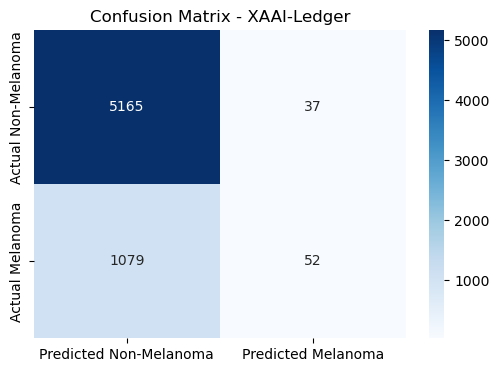

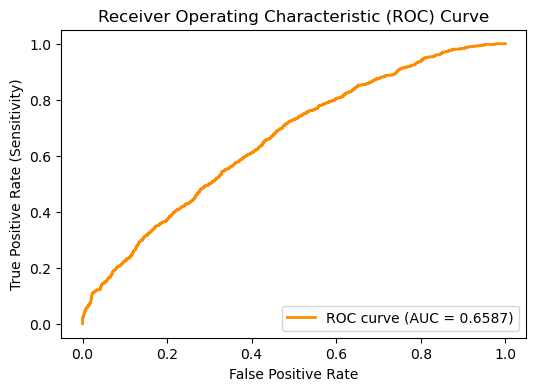

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# 1. Validation Dataset se True Labels (Actual Answers) nikalna
y_true = np.concatenate([y for x, y in val_dataset], axis=0)

# 2. Model se Predictions karwana
print("Generating predictions on validation data...")
y_pred_probs = model.predict(val_dataset) # Yeh 0 se 1 ke beech probabilities dega
y_pred_binary = (y_pred_probs > 0.5).astype(int) # 0.5 se upar Melanoma (1), warna Non-Melanoma (0)

# ==========================================
# RESULT 1: Classification Report
# ==========================================
print("\n--- Final Classification Report ---")
print(classification_report(y_true, y_pred_binary, target_names=['Non-Melanoma', 'Melanoma']))

# ==========================================
# RESULT 2: Confusion Matrix (Visual)
# ==========================================
cm = confusion_matrix(y_true, y_pred_binary)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Non-Melanoma', 'Predicted Melanoma'], 
            yticklabels=['Actual Non-Melanoma', 'Actual Melanoma'])
plt.title('Confusion Matrix - XAAI-Ledger')
plt.show()

# ==========================================
# RESULT 3: ROC Curve & AUC Score
# ==========================================
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot( color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()